# Merchant ETL

In [1]:
# libraries
from pyspark.sql import SparkSession
import pandas as pd
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, DateType, StringType, IntegerType
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Merchant")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/11 00:45:50 WARN Utils: Your hostname, MacBook-Pro-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.20 instead (on interface en0)
26/09/11 00:45:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/11 00:45:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# helper function to peek at a Spark DataFrame
def peek(df, n=5):
    # print n heads and total number of rows of a Spark DataFrame
    total = df.count()
    df.show(n, truncate=False)
    print(f"-> {total} rows total")

## Load raw tables

In [4]:
merchants_raw = spark.read.parquet("../data/tables/tbl_merchants.parquet")

fraud_schema = StructType([
    StructField("merchant_abn", LongType(), True),
    StructField("order_datetime", DateType(), True),
    StructField("fraud_probability", DoubleType(), True),
])
merchant_fraud = spark.read.csv(
    "../data/tables/merchant_fraud_probability.csv",
    schema=fraud_schema,
    header=True
)

peek(merchants_raw)
peek(merchant_fraud)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+
|name                                |tags                                                                                                             |merchant_abn|
+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+
|Felis Limited                       |((furniture, home furnishings and equipment shops, and manufacturers, except appliances), (e), (take rate: 0.18))|10023283211 |
|Arcu Ac Orci Corporation            |([cable, satellite, and otHer pay television and radio services], [b], [take rate: 4.22])                        |10142254217 |
|Nunc Sed Company                    |([jewelry, watch, clock, and silverware shops], [b], [take rate: 4.40])                                          |10165489824 |
|Ult

## Parse merchant tags

In [5]:
# 3 columns of interest in the `tags` column: category, revenue band, and take rate
tag_pattern = r'[\(\[](.+?)[\)\]],\s*[\(\[]([a-eA-E])[\)\]],\s*[\(\[]take rate:\s*([\d.]+)[\)\]]'

merchants_parsed = (
    merchants_raw
    .withColumn("category_raw", F.regexp_extract("tags", tag_pattern, 1))
    .withColumn("revenue_band_raw", F.regexp_extract("tags", tag_pattern, 2))
    .withColumn("take_rate_raw", F.regexp_extract("tags", tag_pattern, 3))
    .withColumn("category", F.trim(F.regexp_replace("category_raw", r'^[\[\(]+|[\]\)]+$', '')))
    .withColumn("revenue_band", F.when(F.col("revenue_band_raw") == "", None).otherwise(F.lower(F.col("revenue_band_raw"))))
    .withColumn("take_rate", F.when(F.col("take_rate_raw") == "", None).otherwise(F.col("take_rate_raw").cast(DoubleType())))
    .drop("category_raw", "revenue_band_raw", "take_rate_raw")
)

peek(merchants_parsed)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------+------------+---------+
|name                                |tags                                                                                                             |merchant_abn|category                                                                             |revenue_band|take_rate|
+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------+------------+---------+
|Felis Limited                       |((furniture, home furnishings and equipment shops, and manufacturers, except appliances), (e), (take rate: 0.18))|10023283211 |furniture,

## Data quality checks

In [6]:
null_counts = merchants_parsed.select(
    F.count(F.when(F.col("category").isNull() | (F.col("category") == ""), "category")).alias("category"),
    F.count(F.when(F.col("revenue_band").isNull() | (F.col("revenue_band") == ""), "revenue_band")).alias("revenue_band"),
    F.count(F.when(F.col("take_rate").isNull(), "take_rate")).alias("take_rate"),
)
null_counts.show()

dup_count = merchants_parsed.groupBy("merchant_abn").count().filter(F.col("count") > 1).count()
print(f"Duplicate merchant_abn: {dup_count}")

merchants_parsed.select(
    F.min("take_rate").alias("min_rate"),
    F.max("take_rate").alias("max_rate")
).show()

merchants_parsed.select("revenue_band").distinct().orderBy("revenue_band").show()

+--------+------------+---------+
|category|revenue_band|take_rate|
+--------+------------+---------+
|       0|           0|        0|
+--------+------------+---------+

Duplicate merchant_abn: 0
+--------+--------+
|min_rate|max_rate|
+--------+--------+
|     0.1|     7.0|
+--------+--------+

+------------+
|revenue_band|
+------------+
|           a|
|           b|
|           c|
|           d|
|           e|
+------------+



## Load and aggregate transactions

In [7]:
transactions_1 = spark.read.parquet("../data/tables/transactions_20210228_20210827_snapshot/")
transactions_2 = spark.read.parquet("../data/tables/transactions_20210828_20220227_snapshot/")
transactions_3 = spark.read.parquet("../data/tables/transactions_20220228_20220828_snapshot/")

transactions = transactions_1.unionByName(transactions_2).unionByName(transactions_3)
peek(transactions)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|18478  |62191208634 |63.255848959735246|949a63c8-29f7-4ab0-ada4-99ac50a88952|2021-08-20    |
|2      |15549624934 |130.3505283105634 |6a84c3cf-612a-4574-835b-144a47353eff|2021-08-20    |
|18479  |64403598239 |120.15860593212783|b10dcc33-e53f-4254-863c-de5266810cbc|2021-08-20    |
|3      |60956456424 |136.6785200286976 |0f09c5a5-784e-4477-b049-8ee4dd069b7b|2021-08-20    |
|18479  |94493496784 |72.96316578355305 |f6c78c1a-4600-4c5f-8e97-6e9eb534b586|2021-08-20    |
+-------+------------+------------------+------------------------------------+--------------+
only showing top 5 rows
-> 14195505 rows total


In [8]:
# aggregate transactions by merchant_abn to get total revenue, number of transactions, and average order value
merchant_txn_summary = transactions.groupBy("merchant_abn").agg(
    F.sum("dollar_value").alias("total_revenue"),
    F.count("dollar_value").alias("n_transactions"),
    F.avg("dollar_value").alias("avg_order_value"),
)
peek(merchant_txn_summary)

+------------+------------------+--------------+------------------+
|merchant_abn|total_revenue     |n_transactions|avg_order_value   |
+------------+------------------+--------------+------------------+
|38700038932 |9546185.360697314 |7132          |1338.500471213869 |
|83412691377 |498536.5816973136 |14288         |34.89197800233158 |
|15613631617 |543030.531332826  |1785          |304.21878506040673|
|19839532017 |113982.0          |726           |157.0             |
|73256306726 |1496967.1591142188|5263          |284.4322932004976 |
+------------+------------------+--------------+------------------+
only showing top 5 rows
-> 4422 rows total


## Merge and save

In [9]:
# take the average fraud probability for each merchant
merchant_fraud_summary = merchant_fraud.groupBy("merchant_abn").agg(
    F.avg("fraud_probability").alias("avg_fraud_probability")
)

merchant_final = (
    merchants_parsed
    .join(merchant_txn_summary, on="merchant_abn", how="left")
    .join(merchant_fraud_summary, on="merchant_abn", how="left")
)

peek(merchant_final)

+------------+------------------------+-----------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------+------------+---------+------------------+--------------+------------------+---------------------+
|merchant_abn|name                    |tags                                                                                                             |category                                                                             |revenue_band|take_rate|total_revenue     |n_transactions|avg_order_value   |avg_fraud_probability|
+------------+------------------------+-----------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------+------------+---------+------------------+--------------+------------------+---------

In [10]:
# save raw merchant data to parquet
merchant_final.write.mode("overwrite").parquet("../data/raw/merchant/")

## Filter and save curated

In [11]:
# Only keep merchants with at least 1 transaction
merchant_curated = merchant_final.filter(F.col("n_transactions").isNotNull())

print(f"Before filtering: {merchant_final.count()}")
print(f"After filtering: {merchant_curated.count()}")

merchant_curated.write.mode("overwrite").parquet("../data/curated/merchant/")

Before filtering: 4026


After filtering: 4026


## Outliers

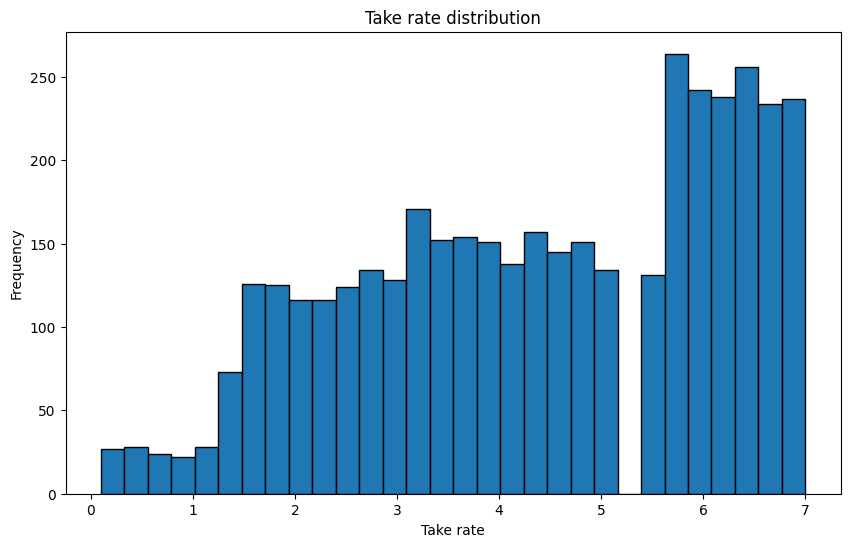

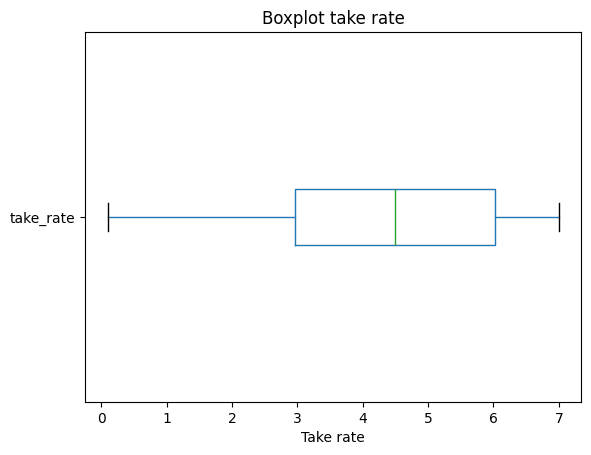

In [12]:
pdf_merchant = merchant_final.select("take_rate", "total_revenue").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_merchant["take_rate"], bins=30, edgecolor="black")
plt.xlabel("Take rate")
plt.ylabel("Frequency")
plt.title("Take rate distribution")
plt.show()

pdf_merchant.boxplot(column="take_rate", vert=False, grid=False)
plt.xlabel("Take rate")
plt.title("Boxplot take rate")
plt.show()

## Merchant category trends

In [13]:
# average take rate by category
category_take_rate = (
    merchant_curated
    .groupBy("category")
    .agg(
        F.avg("take_rate").alias("avg_take_rate"),
        F.count("merchant_abn").alias("n_merchants")
    )
    .orderBy(F.desc("avg_take_rate"))
)
peek(category_take_rate, 10)

+--------------------------------------------------------------------------------------+-------------+-----------+
|category                                                                              |avg_take_rate|n_merchants|
+--------------------------------------------------------------------------------------+-------------+-----------+
|furniture, home furnishinGs and equiPment shops, and  manufacturers, except appliances|6.99         |1          |
|gift, carD, novelty, and souvenir shops                                               |6.99         |1          |
|anTique shops - sales, repairs, and restoration Services                              |6.99         |1          |
|computers,  computer peripheral equipment, and  Software                              |6.99         |1          |
|compUTer programming , data processing, and integrated systEms design services        |6.99         |1          |
|computer programming , data processing, and iNtegratEd systems design services 

In [14]:
# category with the highest total transaction volume and revenue
category_volume = (
    merchant_curated
    .groupBy("category")
    .agg(
        F.sum("n_transactions").alias("total_transactions"),
        F.sum("total_revenue").alias("total_revenue"),
        F.avg("avg_order_value").alias("avg_order_value")
    )
    .orderBy(F.desc("total_transactions"))
)

peek(category_volume, 10)

+-------------------------------------------------------------+------------------+--------------------+------------------+
|category                                                     |total_transactions|total_revenue       |avg_order_value   |
+-------------------------------------------------------------+------------------+--------------------+------------------+
|tent and awning shops                                        |1300425           |1.1466846375272241E8|628.3459863875084 |
|gift, card, novelty, and souvenir shops                      |983678            |6.878972790287939E7 |74.75319565118602 |
|digital goods: books, movies, music                          |852290            |5.563480325287594E7 |70.15632008113039 |
|watch, clock, and jewelry repair shops                       |773175            |5.132791165748829E7 |100.89438456388172|
|cable, satellite, and other pay television and radio services|684340            |5.283103263032809E7 |88.79170306894432 |
|opticians, opti

In [15]:
# merchants with the highest take rate
top_take_rate_merchants = (
    merchant_curated
    .select("merchant_abn", "category", "take_rate", "n_transactions", "total_revenue")
    .orderBy(F.desc("take_rate"))
)
peek(top_take_rate_merchants, 10)

+------------+--------------------------------------------------------------------------------------+---------+--------------+------------------+
|merchant_abn|category                                                                              |take_rate|n_transactions|total_revenue     |
+------------+--------------------------------------------------------------------------------------+---------+--------------+------------------+
|96161808980 |digital goods: books, movies, music                                                   |7.0      |13540         |1150344.8388259746|
|40305723628 |computer programming , data processing, and integrated systems design services        |7.0      |688           |96787.16693522135 |
|57011992135 |computers, computer peripheral equipment, and software                                |7.0      |1900          |98011.03825094028 |
|99319455478 |watch, clock, and jewelry repair shops                                                |6.99     |524          

In [16]:
# merchant bring the most profit (estimated profit = total revenue * take rate)
merchant_profit = (
    merchant_curated
    .withColumn("estimated_profit", F.col("total_revenue") * F.col("take_rate") / 100)
    .select("merchant_abn", "category", "take_rate", "total_revenue", "n_transactions", "estimated_profit")
    .orderBy(F.desc("estimated_profit"))
)
peek(merchant_profit, 10)

+------------+-------------------------------------------------------------------------------------+---------+-----------------+--------------+-----------------+
|merchant_abn|category                                                                             |take_rate|total_revenue    |n_transactions|estimated_profit |
+------------+-------------------------------------------------------------------------------------+---------+-----------------+--------------+-----------------+
|79827781481 |furniture, home furnishings and equipment shops, and manufacturers, except aPpliances|6.82     |9734168.478418225|4798          |663870.290228123 |
|48534649627 |opticians, oPtical goods, and eyeglasses                                             |6.64     |9408958.320743632|66437         |624754.8324973771|
|32361057556 |gift, card, novelty, and souvenir shops                                              |6.61     |9434452.552354382|85780         |623617.3137106247|
|86578477987 |watch, clock, 

## Merchant size segmentation

In [17]:
merchant_curated = merchant_curated.withColumn(
    "merchant_size",
    F.when(F.col("n_transactions") >= 5000, "large_chain")
     .when(F.col("n_transactions") >= 500, "medium")
     .otherwise("small_boutique")
)
merchant_curated.groupBy("merchant_size").count().orderBy(F.desc("count")).show()

+--------------+-----+
| merchant_size|count|
+--------------+-----+
|small_boutique| 2178|
|        medium| 1300|
|   large_chain|  548|
+--------------+-----+



In [18]:
size_summary = (
    merchant_curated
    .groupBy("merchant_size")
    .agg(
        F.avg("take_rate").alias("avg_take_rate"),
        F.avg("avg_fraud_probability").alias("avg_fraud_probability"),
        F.avg("total_revenue").alias("avg_total_revenue"),
        F.avg("avg_order_value").alias("avg_order_value"),
        F.count("merchant_abn").alias("n_merchants")
    )
    .orderBy(F.desc("avg_total_revenue"))
)
peek(size_summary)

+--------------+-----------------+---------------------+------------------+------------------+-----------+
|merchant_size |avg_take_rate    |avg_fraud_probability|avg_total_revenue |avg_order_value   |n_merchants|
+--------------+-----------------+---------------------+------------------+------------------+-----------+
|large_chain   |4.552481751824814|29.6169545688717     |2004847.2627197925|141.87223786714165|548        |
|medium        |4.47786923076923 |50.25231238928743    |603851.2665925866 |381.7217926003611 |1300       |
|small_boutique|4.310674931129485|53.661547467098146   |125524.72271583161|1879.9579174900734|2178       |
+--------------+-----------------+---------------------+------------------+------------------+-----------+

-> 3 rows total
